In [1]:
from pathlib import Path
import sys
code_path = Path.cwd().parents[0] / "code"
sys.path.insert(0, str(code_path))
from utils import *
from martin import *
import networkx as nx, random
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx, random

## Import Markov chain

In [2]:
# Import the Markov chain with N=40 states
markov_graph = open_graph("example (Markov chain)")

# Compute the number of directed transitions in the Markov chain.
s_sum = sum(len(markov_graph[row][1]) for row in markov_graph)
walkers = s_sum
print(f"The Markov chain has {len(markov_graph)} states and {s_sum} transitions")
print(f"At least {s_sum} walkers are required for the exact Markov-chain reconstruction. Number of walkers is set to {walkers}")

The Markov chain has 40 states and 138 transitions
At least 138 walkers are required for the exact Markov-chain reconstruction. Number of walkers is set to 138


### Compute stationary statistics

In [3]:
obj = compute_ss_contact_probabilities(markov_graph, n_walkers=walkers)

Computing stationary contact probabilities:   0%|          | 0/12 [00:00<?, ?it/s]

Computing stationary contact probabilities:   0%|          | 0/12 [00:00<?, ?it/s]

### Vizualize initial Markov chain

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

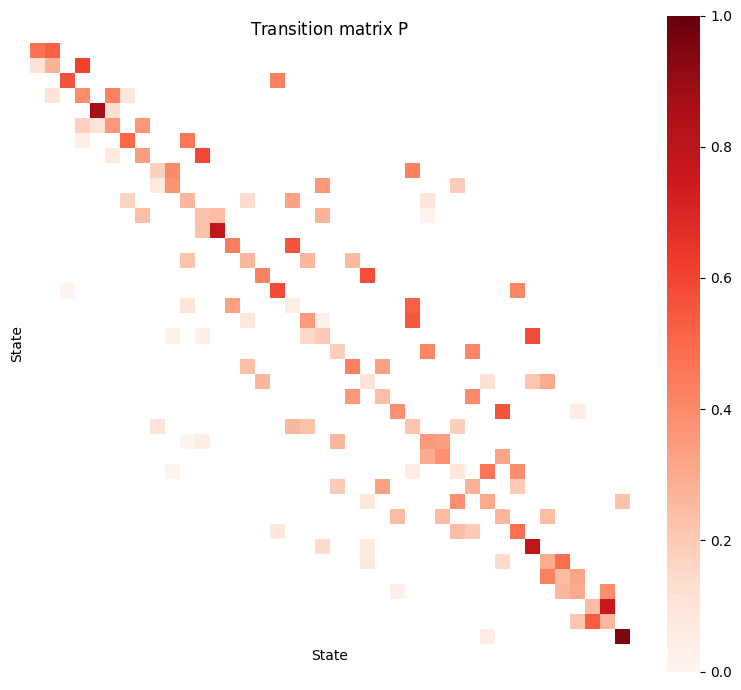

In [4]:
# Construct and visualize the transition matrix P.
markov_chain = dict_to_markov_chain(markov_graph)
nodes = list(markov_chain.nodes())
P = nx.to_numpy_array(
    markov_chain,
    nodelist=nodes,
    weight="weight",
)

ss = np.array([float(x) for x in obj["ss_vector"]])
# Sort states by decreasing steady-state probability.
order = np.argsort(ss)

P_sorted = P[np.ix_(order, order)]
ss_sorted = ss[order]
mask = (P_sorted == 0)
plt.figure(figsize=(8, 7))

sns.heatmap(
    P_sorted,
    mask=mask,
    cmap="Reds",
    vmin=0,
    vmax=1,
    square=True,
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

plt.xlabel("State")
plt.ylabel("State")
plt.title("Transition matrix $P$")

plt.tight_layout()
plt.show()

## Apply MARTIN

In [5]:
output = recover_markov_chain(obj['prob'], obj['joint_prob'], max_group=5)

Estimating steady-state vector... Preparing coefficients...


Computing coefficients from power sums…:   0%|          | 0/138 [00:00<?, ?it/s]

Done. Number of states is 40
Estimating elements of W matrix... Preparing coefficients...


Computing coefficients from power sums…:   0%|          | 0/138 [00:00<?, ?it/s]

Done. Number of elements in W is 138


Allocating elements to rows of matrix W...:   0%|          | 0/40 [00:00<?, ?it/s]

Allocating elements to rows of matrix W... finished.


Processing rows:   0%|          | 0/40 [00:00<?, ?it/s]

Allocating elements to W... Done. Found 2 solutions.


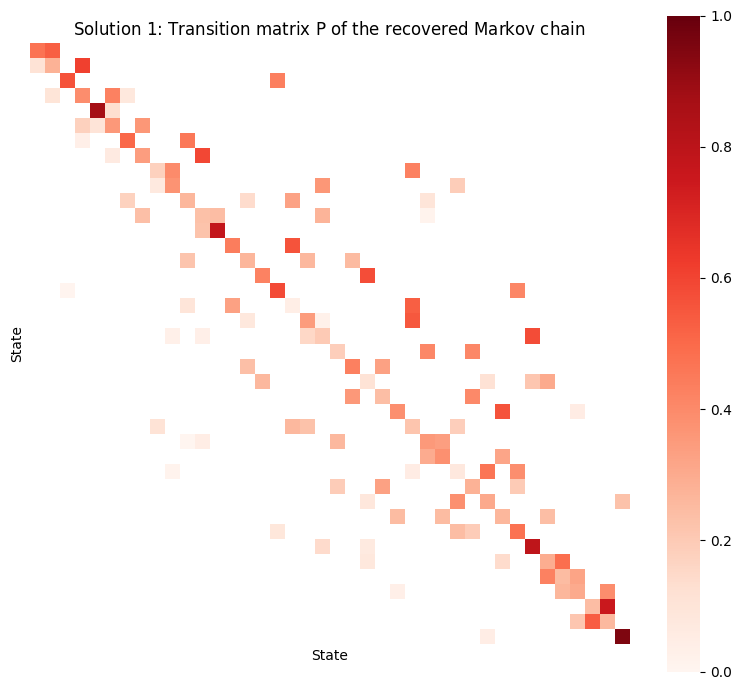

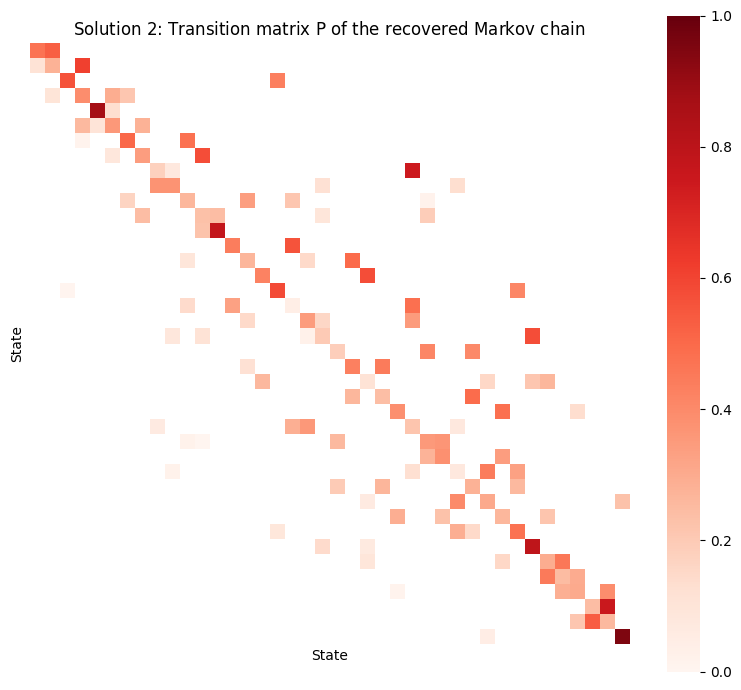

In [6]:
for i, matrix in enumerate(output["markov chains"]):
    p_matrix = np.array(matrix, dtype=float)

    plt.figure(figsize=(8, 7))

    sns.heatmap(
        p_matrix,
        cmap="Reds",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=False,
        yticklabels=False
    )

    plt.xlabel("State")
    plt.ylabel("State")
    plt.title(f"Solution {i+1}: Transition matrix $P$ of the recovered Markov chain")
    plt.tight_layout()
    plt.show()